# 27 — Ce que la vie privée coûte à l'audit

La [demande au titre de l'article 40](../article-40.md) prouve qu'un régulateur n'a pas besoin du
journal : quatre tableaux agrégés suffisent à recalculer toutes les mesures de ce dépôt, pour 95
fois moins de lignes. Elle ne dit rien de leur **innocuité**.

C'est une lacune que le dépôt s'était signalée à lui-même, et laissée ouverte :

> Un protocole d'audit crédible doit être agrégatif et **différentiellement privé** — ce dépôt ne
> le propose pas.

Un agrégat n'est pas anonyme. Le seuil de suppression des faibles effectifs employé jusqu'ici
n'offre **aucune garantie formelle** : il rend seulement l'attaque plus laborieuse.

Ce chapitre publie ce qui manquait, et mesure ce que cela coûte — quantité par quantité, parce
que la réponse n'est pas la même pour toutes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.ebnerd import load_digest as load_ebnerd_digest, load_index_table
from ide.exposure import examination_counts, load_digest as load_exposure_digest
from ide.offpolicy import estimate_position_bias
from ide.privacy import clipped_histogram, laplace_counts, publication_threshold
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()
DEPTH, TRUTH = 9, 0.882

counts = examination_counts(load_exposure_digest())
shallow = counts["ranks"] <= DEPTH
items, ranks = counts["items"][shallow], counts["ranks"][shallow]
exposures = counts["exposures"][shallow].astype(float)
seen = counts["seen"][shallow].astype(float)

print(f"tableau 3 de la demande : {items.size:,} cellules (contenu, rang)".replace(",", " "))
print(f"  exposition médiane par cellule : {np.median(exposures):.0f}")
print(f"  cellules portant moins de 5 impressions : {(exposures < 5).mean():.1%}")

tableau 3 de la demande : 451 100 cellules (contenu  rang)
  exposition médiane par cellule : 1
  cellules portant moins de 5 impressions : 99.7%


## 1. Deux coûts, et ce n'est pas celui qu'on croit qui domine

Le **bruit** protège contre l'inférence sur une ligne du journal. Son effet dépend de la
*densité* du tableau : invisible sur neuf cellules portant des millions d'impressions, fatal sur
un tableau dont 99,7 % des cellules en portent moins de cinq.

Le **plafonnement des contributions** est ce qui rend possible une garantie *par utilisateur* :
on ne retient au plus que $C$ observations par personne. C'est un choix de conception, et c'est
lui qui déplace les chiffres.

## 2. La grandeur réglementée : le bruit ne coûte presque rien

La grandeur que le [protocole](../ide.md) prescrit est la **part de la population sous le
plancher**, mesurée par journée-utilisateur. Sur EB-NeRD, c'est un histogramme de 50 classes sur
58 549 journées.

In [2]:
table, edges = load_index_table(load_ebnerd_digest())
centres = (edges[:-1] + edges[1:]) / 2
sans_plafond = clipped_histogram(table, cap=table.shape[0])
part = lambda histogramme: float(histogramme[centres < 0.40].sum() / histogramme.sum())
reference = part(sans_plafond)
print(f"part sous 0,40, sans plafonnement ni bruit : {reference:.4f}\n")

generator = np.random.default_rng(20260826)
BUDGETS = (10.0, 3.0, 1.0, 0.3, 0.1)
mesures = {}
print("plafond   journées gardées   biais du plafond   " +
      "   ".join(f"ε={budget:g}" for budget in BUDGETS))
for cap in (1, 2, 3, 5, 8):
    borne = clipped_histogram(table, cap)
    tirages = {budget: [part(laplace_counts(borne, budget, sensitivity=cap, rng=generator))
                        for _ in range(300)] for budget in BUDGETS}
    mesures[cap] = (borne.sum() / sans_plafond.sum(), part(borne) - reference, tirages)
    ligne = "   ".join(f"{np.mean(tirages[budget]):.3f}" for budget in BUDGETS)
    print(f"{cap:>6}   {mesures[cap][0]:>15.3f}   {mesures[cap][1]:>+16.4f}   {ligne}")

part sous 0,40, sans plafonnement ni bruit : 0.1878

plafond   journées gardées   biais du plafond   ε=10   ε=3   ε=1   ε=0.3   ε=0.1
     1             0.259            +0.0253   0.213   0.213   0.213   0.213   0.213
     2             0.463            +0.0187   0.206   0.206   0.206   0.206   0.206
     3             0.626            +0.0135   0.201   0.201   0.201   0.201   0.201
     5             0.855            +0.0062   0.194   0.194   0.194   0.194   0.194
     8             1.000            +0.0000   0.188   0.188   0.188   0.187   0.188


**Le bruit est invisible jusqu'à $\varepsilon = 0{,}1$.** À plafond fixé, la part sous le plancher
ne bouge pas d'un millième entre $\varepsilon = 10$ et $\varepsilon = 0{,}1$ : l'écart type des
tirages reste sous un demi-point.

**Le plafonnement, lui, déplace le chiffre, et toujours dans le même sens.** Retenir une seule
journée par lecteur ajoute $2{,}5$ points à une part de $18{,}8$ % — un excès relatif de 13 %.
Les lecteurs assidus ne ressemblent pas aux autres : leur exposition est **plus diverse**, et les
écarter fait paraître la plateforme moins conforme qu'elle n'est.

C'est un résultat inattendu et il va dans le sens de la sévérité : sous garantie par utilisateur,
un régulateur **surestime** la non-conformité.

## 3. La grandeur dont elle dépend : le bruit détruit tout

L'indice exposé se calcule avec une remise d'attention $R^{-\eta}$, et $\eta$ s'estime sur le
tableau 3 — les cellules (contenu, rang). Les effets fixes de contenu sont ce qui rend
l'estimation identifiable : sans eux, la courbe mélange la popularité et la position.

In [3]:
def severite(garde, expositions, vus):
    total = np.round(np.maximum(expositions[garde], 1.0)).astype(int)
    hits = np.round(np.clip(np.minimum(vus[garde], expositions[garde]), 0.0, None)).astype(int)
    flags = np.concatenate([np.concatenate([np.ones(h), np.zeros(t - h)])
                            for t, h in zip(total, hits)])
    return estimate_position_bias(np.repeat(items[garde], total), np.repeat(ranks[garde], total),
                                  flags, minimum_impressions=5)


tout = np.ones(items.size, dtype=bool)
base = severite(tout, exposures, seen)
print(f"sans bruit : η = {base.severity:.3f} ± {base.standard_error:.3f} "
      f"sur {base.items_with_variation} contenus\n")

print("  ε    η bruité   erreur type   |   seuil τ   η après seuil   contenus retenus")
brut, seuille = {}, {}
for budget in (10.0, 3.0, 1.0, 0.3):
    bruit_e = laplace_counts(exposures, budget, sensitivity=2.0, rng=generator)
    bruit_v = laplace_counts(seen, budget, sensitivity=2.0, rng=generator)
    sale = severite(tout, bruit_e, bruit_v)
    brut[budget] = sale.severity

    tau = publication_threshold(budget, delta=1e-6, sensitivity=2.0)
    garde = bruit_e >= tau
    propre = severite(garde, bruit_e, bruit_v)
    seuille[budget] = (propre.severity, propre.items_with_variation)
    print(f"{budget:>5.1f}   {sale.severity:>8.3f}   {sale.standard_error:>11.3f}   |"
          f"{tau:>9.0f}   {propre.severity:>13.3f}   {propre.items_with_variation:>16}")

sans bruit : η = 0.882 ± 0.046 sur 143 contenus

  ε    η bruité   erreur type   |   seuil τ   η après seuil   contenus retenus


 10.0      0.871         0.047   |        4           0.871                145


  3.0      0.797         0.052   |       10           0.881                 57


  1.0      0.505         0.051   |       29           1.034                 25


  0.3      0.151         0.050   |       93           1.201                  9


**À $\varepsilon = 1$ — la valeur de référence usuelle — la sévérité est divisée par deux**, et
son erreur type ne bouge pas. Le bruit sur les effectifs agit comme une erreur de mesure : il
**atténue** l'estimation vers zéro, sans que rien ne le signale. C'est le mode d'échec que ce
dépôt a rencontré cinq fois : un chiffre plausible, un intervalle serré, une conclusion fausse.

Et la conséquence est **directionnelle** : une sévérité sous-estimée fait paraître l'attention
plus plate qu'elle n'est, donc l'enterrement moins grave. Un régulateur appliquant la
confidentialité différentielle au tableau tel qu'il est demandé **sous-estimerait la relégation**.

**Le seuil de publication corrige le niveau, puis le dépasse.** Ne publier que les cellules dont
l'effectif bruité dépasse $\tau$ échange un biais d'atténuation contre un biais de **sélection** :
les cellules qui survivent sont les plus exposées, donc les premiers rangs et les contenus
populaires. À $\varepsilon = 3$ l'échange est bon — $\eta = 0{,}88$ retrouvé, sur 57 contenus au
lieu de 143. En dessous il tourne mal : $1{,}03$ à $\varepsilon = 1$ sur 25 contenus, $1{,}20$ à
$\varepsilon = 0{,}3$ sur neuf. Le remède ne supprime pas l'erreur, il en change le signe.

## 4. Ce qui se publie sans risque est ce qu'on ne peut pas vérifier

In [4]:
marge_e = np.bincount(ranks, weights=exposures)[1:DEPTH + 1]
marge_v = np.bincount(ranks, weights=seen)[1:DEPTH + 1]
pente = lambda e, v: -np.polyfit(np.log(np.arange(1, DEPTH + 1)), np.log(v / e), 1)[0]
print(f"marge de rang, {DEPTH} cellules, {marge_e.sum():,.0f} impressions".replace(",", " "))
print(f"  η de la marge, sans bruit : {pente(marge_e, marge_v):.3f}   "
      f"contre {base.severity:.3f} à contenu fixé\n")

marge = {}
for budget in (1.0, 0.3, 0.1, 0.03):
    tirages = [pente(laplace_counts(marge_e, budget, sensitivity=2.0, rng=generator),
                     laplace_counts(marge_v, budget, sensitivity=2.0, rng=generator))
               for _ in range(200)]
    marge[budget] = float(np.mean(tirages))
    print(f"  ε = {budget:>5.2f} : η = {np.mean(tirages):.3f} ± {np.std(tirages):.3f}")

marge de rang  9 cellules  506 953 impressions
  η de la marge, sans bruit : 0.876   contre 0.882 à contenu fixé

  ε =  1.00 : η = 0.876 ± 0.000
  ε =  0.30 : η = 0.875 ± 0.000
  ε =  0.10 : η = 0.875 ± 0.001
  ε =  0.03 : η = 0.875 ± 0.003


La marge de rang survit à $\varepsilon = 0{,}03$ : neuf cellules portant des centaines de
milliers d'impressions chacune sont hors d'atteinte du bruit. Et sur ce journal, elle tombe à
**0,7 % de la valeur à contenu fixé**.

C'est le nœud de ce chapitre, et il ne se dénoue pas :

> **La quantité qui se publie sans risque est celle qu'on ne peut pas vérifier ; celle qui se
> vérifie est celle qu'on ne peut pas publier.**

On ne sait que la marge est fidèle que parce qu'on dispose du tableau à contenu fixé — celui
qu'aucune garantie ne protège. Sur une plateforme où la composition varierait davantage avec le
rang, la marge pourrait être fausse **sans que rien ne le montre**.

## 5. La figure

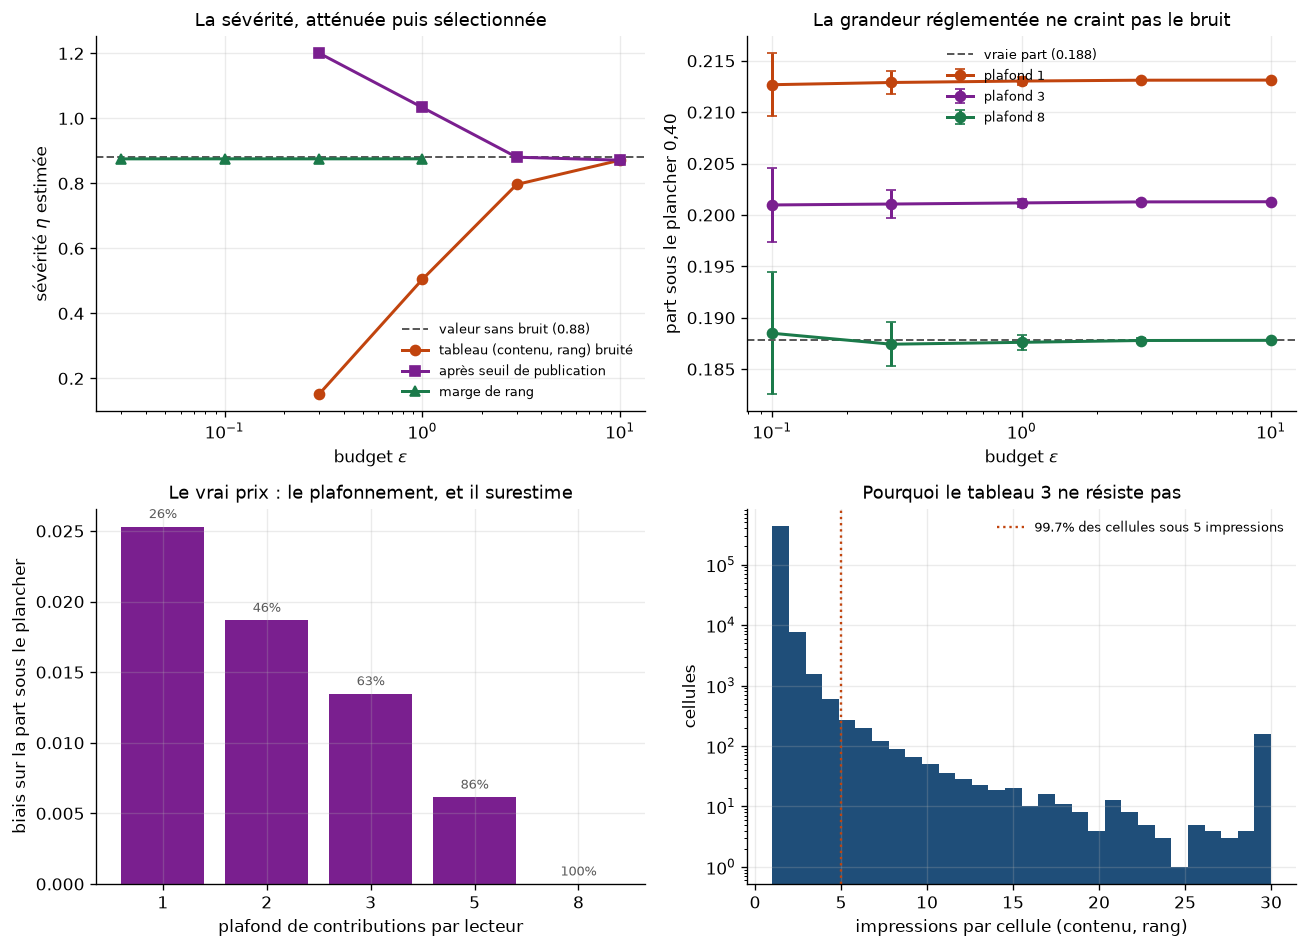

In [5]:
figure, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
budgets = sorted(brut)
ax.axhline(base.severity, color=PALETTE["neutral"], linestyle="--", linewidth=1.2,
           label=f"valeur sans bruit ({base.severity:.2f})")
ax.plot(budgets, [brut[b] for b in budgets], marker="o", color=PALETTE["disorder"],
        label="tableau (contenu, rang) bruité")
ax.plot(budgets, [seuille[b][0] for b in budgets], marker="s", color=PALETTE["field"],
        label="après seuil de publication")
ax.plot(sorted(marge), [marge[b] for b in sorted(marge)], marker="^", color=PALETTE["remedy"],
        label="marge de rang")
ax.set(xscale="log", xlabel="budget $\\varepsilon$", ylabel="sévérité $\\eta$ estimée",
       title="La sévérité, atténuée puis sélectionnée")
ax.legend(fontsize=8)

ax = axes[0, 1]
for cap, couleur in zip((1, 3, 8), (PALETTE["disorder"], PALETTE["field"], PALETTE["remedy"])):
    valeurs = [np.mean(mesures[cap][2][b]) for b in BUDGETS]
    erreurs = [np.std(mesures[cap][2][b]) for b in BUDGETS]
    ax.errorbar(BUDGETS, valeurs, yerr=erreurs, marker="o", capsize=3, color=couleur,
                label=f"plafond {cap}")
ax.axhline(reference, color=PALETTE["neutral"], linestyle="--", linewidth=1.2,
           label=f"vraie part ({reference:.3f})")
ax.set(xscale="log", xlabel="budget $\\varepsilon$", ylabel="part sous le plancher 0,40",
       title="La grandeur réglementée ne craint pas le bruit")
ax.legend(fontsize=8)

ax = axes[1, 0]
caps = sorted(mesures)
ax.bar([str(cap) for cap in caps], [mesures[cap][1] for cap in caps], color=PALETTE["field"])
for position, cap in enumerate(caps):
    ax.text(position, mesures[cap][1] + 0.0006, f"{mesures[cap][0]:.0%}", ha="center", fontsize=8,
            color=PALETTE["neutral"])
ax.set(xlabel="plafond de contributions par lecteur",
       ylabel="biais sur la part sous le plancher",
       title="Le vrai prix : le plafonnement, et il surestime")

ax = axes[1, 1]
ax.hist(np.clip(exposures, 0, 30), bins=30, color=PALETTE["order"])
ax.axvline(5, color=PALETTE["disorder"], linestyle=":", linewidth=1.4,
           label=f"{(exposures < 5).mean():.1%} des cellules sous 5 impressions")
ax.set(yscale="log", xlabel="impressions par cellule (contenu, rang)", ylabel="cellules",
       title="Pourquoi le tableau 3 ne résiste pas")
ax.legend(fontsize=8)

save_figure(figure, "fig27_vie_privee.png")
plt.show()

## 6. Ce que ce chapitre change à la demande

**Un budget par quantité, publié avec elle.** Les budgets ne se composent pas gratuitement :
publier deux tableaux sous $\varepsilon$ chacun donne une garantie à $2\varepsilon$. Une demande
réelle doit les additionner et le dire.

**Le tableau 3 ne doit pas être demandé tel quel.** Sous confidentialité différentielle, il rend
une sévérité fausse d'un facteur deux et confiante. Ce qu'il faut demander à sa place :

1. la **marge de rang** des affichages, publiable à $\varepsilon = 0{,}1$ sans dommage ;
2. l'**estimation à effets fixes de contenu calculée par la plateforme elle-même**, et publiée
   comme un scalaire bruité — un nombre a une sensibilité bornée, un tableau creux non ;
3. l'**écart entre les deux**, qui est le seul contrôle disponible de la première par la seconde.

**Et le plafond de contributions doit être publié avec le résultat**, comme l'est déjà le seuil de
suppression. Il n'est pas neutre : il déplace la part sous le plancher de $+0{,}6$ à $+2{,}5$
points, toujours vers l'excès de sévérité.

**Réserves.** Le mécanisme employé est le plus simple — bruit de Laplace sur des effectifs, seuil
de publication pour la garantie $(\varepsilon, \delta)$. Des mécanismes mieux adaptés aux
tableaux creux existent et feraient mieux ; ce chapitre borne le coût par le haut, il ne prétend
pas l'atteindre. La garantie par utilisateur n'est mesurée que sur EB-NeRD, seul journal du dépôt
qui porte un identifiant de lecteur : sur Baidu-ULTR, seule une garantie **par impression** est
possible, ce qui est plus faible et tient au jeu de données, non à la méthode.